In [1]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("/content/Job_3_Resource_sentiment (1).csv")
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
df.rename(columns={'Positive': 'sentiment'}, inplace=True)
df.rename(columns={'im getting on borderlands and i will murder you all ,': 'text'}, inplace=True)
df.columns

Index(['2401', 'Borderlands', 'sentiment', 'text'], dtype='object')

In [6]:
df.isnull().sum()

,0
2401,0
Borderlands,0
sentiment,0
text,686


In [7]:
df.dropna(inplace=True)

In [8]:
df.drop(columns=['2401','Borderlands'],inplace=True)
df.head()

,sentiment,text
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...


In [10]:
df['text'] = df['text'].astype(str)


<class 'pandas.core.frame.DataFrame'>
Index: 73995 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  73995 non-null  object
 1   text       73995 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB


In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

In [12]:
df['text']

,text
0,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you all
2,im coming on borderlands and i will murder you...
3,im getting on borderlands and i will murder y...
4,im getting into borderlands and i can murder y...
...,...
74676,just realized that the windows partition of my...
74677,just realized that my mac window partition is ...
74678,just realized the windows partition of my mac ...
74679,just realized between the windows partition of...


In [13]:
encoder = LabelEncoder()
df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])

print("Label mapping:")
for i, c in enumerate(encoder.classes_):
    print(i, "->", c)

Label mapping:
0 -> Irrelevant
1 -> Negative
2 -> Neutral
3 -> Positive


In [27]:
df.head()

,sentiment,text,sentiment_encoded
0,Positive,i am coming to the borders and i will kill you...,3
1,Positive,im getting on borderlands and i will kill you all,3
2,Positive,im coming on borderlands and i will murder you...,3
3,Positive,im getting on borderlands and i will murder y...,3
4,Positive,im getting into borderlands and i can murder y...,3


In [37]:
len(df['text'][200])

31

In [18]:
max_words = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df['text']),
    maxlen=max_length,
    padding='post'
)

y = df['sentiment_encoded'].values
print("X= ",X)
print("y ",y)

X=  [[   3  101  377 ...    0    0    0]
 [  31  158   14 ...    0    0    0]
 [  31  377   14 ...    0    0    0]
 ...
 [  22 1837    2 ...    0    0    0]
 [  22 1837  693 ...    0    0    0]
 [  22   32    2 ...    0    0    0]]
y  [3 3 3 ... 3 3 3]


In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (51796, 100)
Validation: (11099, 100)
Test: (11100, 100)


In [20]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.4368619618286729), 1: np.float64(0.8274121405750798), 2: np.float64(1.0215367623856106), 3: np.float64(0.8956287176649605)}


In [21]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(max_words, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,332 (10.14 MB)

 Trainable params: 2,659,332 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
early = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early],
    class_weight=class_weights_dict
)

Epoch 1/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6395 - loss: 0.8979 - val_accuracy: 0.7604 - val_loss: 0.6370
Epoch 2/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.8356 - loss: 0.4498 - val_accuracy: 0.8248 - val_loss: 0.4882
Epoch 3/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8882 - loss: 0.3035 - val_accuracy: 0.8506 - val_loss: 0.4302
Epoch 4/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9107 - loss: 0.2380 - val_accuracy: 0.8556 - val_loss: 0.4357
Epoch 5/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9249 - loss: 0.1999 - val_accuracy: 0.8602 - val_loss: 0.4452
Epoch 6/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9355 - loss: 0.1699 - val_accuracy: 0.8652 - val_loss: 0.4633


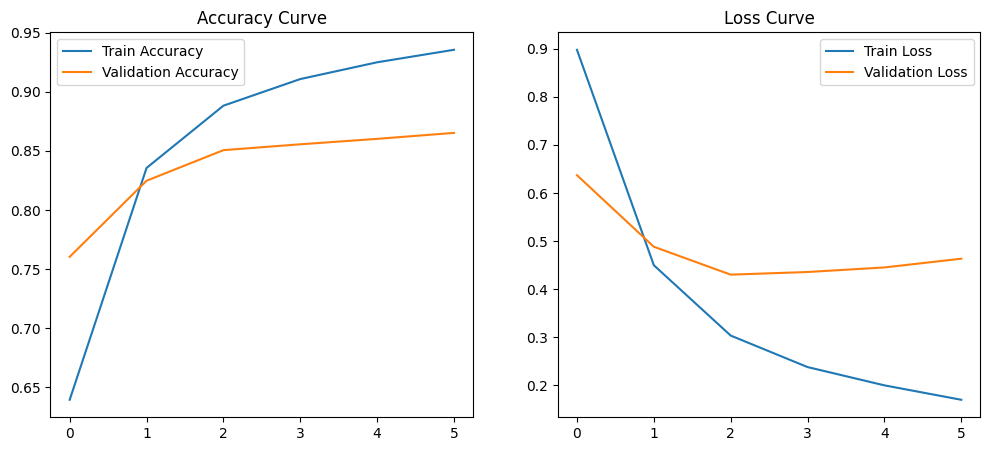

In [25]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("Accuracy curve.png")
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.savefig("Loss curve.png")

plt.show()

Detect Overfitting / Underfitting

In [28]:
if history.history['accuracy'][-1] > history.history['val_accuracy'][-1]:
    print("⚠️ Possible Overfitting detected")
else:
    print("Model is generalizing well")

⚠️ Possible Overfitting detected


Model Evaluation

In [29]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Accuracy: 0.8477477477477477
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1932
           1       0.89      0.85      0.87      3354
           2       0.82      0.84      0.83      2716
           3       0.84      0.86      0.85      3098

    accuracy                           0.85     11100
   macro avg       0.84      0.85      0.85     11100
weighted avg       0.85      0.85      0.85     11100



 Save Model

In [30]:
model.save("sentiment_analysis_model.keras")
print("Model saved successfully")

Model saved successfully
